# Cat and Dog Recognition
### Chosen Model: ResNet-50

**Task:** Binary image classification, specifically predicting whether an image is a cat or a dog.  
**Approach:** Transfer learning from ImageNet pre-trained weights.

## Cell 1 — Install & Import Dependencies

**NOTE:**  
For some reasons current pytorch installation is still using CPU

In [ ]:
# Install required packages (run once)
# !pip install torch torchvision matplotlib seaborn pandas

import os
import time
import copy

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

import torchvision
from torchvision import datasets, transforms, models

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import seaborn as sns

# Reproducibility
torch.manual_seed(42)

# Device: use GPU if available, otherwise CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## Cell 2 — Data Loading & Augmentation

**Reasons for Data Augmentation**  
The training set is artificially expanded by applying random transformations (flips, crops, rotations).  
This prevents overfitting as the model learns to recognise cats and dogs in varied orientations and scales.  
Source: https://www.ibm.com/think/topics/data-augmentation

**Reasons for Data Normalisation?**  
All ImageNet pre-trained models expect inputs normalised with the same mean/std used during their original training.  
Source: https://pytorch.org/vision/stable

In [ ]:
# ── Paths ────────────────────────────────────────────────────────────────────
DATA_DIR = "./cats_and_dogs"
RESULT_DIR = "./results"
TRAIN_DIR = os.path.join(DATA_DIR, "train")
VAL_DIR   = os.path.join(DATA_DIR, "validation")
TEST_DIR  = os.path.join(DATA_DIR, "test")

IMG_SIZE  = 224     # all six models expect 224×224
BATCH     = 32

# ImageNet normalisation statistics (shared by all pre-trained models)
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

# ── Transforms ───────────────────────────────────────────────────────────────
train_tf = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE),   # random crop, to forces size robustness
    transforms.RandomHorizontalFlip(),         # mirror the image randomly
    transforms.ColorJitter(brightness=0.2,
                           contrast=0.2,
                           saturation=0.2),   # slight colour variation
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

eval_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),           # deterministic crop for evaluation
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

# ── Datasets & DataLoaders ────────────────────────────────────────────────────
train_ds  = datasets.ImageFolder(TRAIN_DIR, transform=train_tf)
val_ds    = datasets.ImageFolder(VAL_DIR,   transform=eval_tf)
test_ds   = datasets.ImageFolder(TEST_DIR,  transform=eval_tf)

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)

CLASS_NAMES = train_ds.classes
print(f"Classes : {CLASS_NAMES}")
print(f"Train   : {len(train_ds)} images")
print(f"Val     : {len(val_ds)} images")
print(f"Test    : {len(test_ds)} images")

Classes : ['cats', 'dogs']
Train   : 2000 images
Val     : 1000 images
Test    : 1000 images


## Cell 3 — Visualise Sample Images

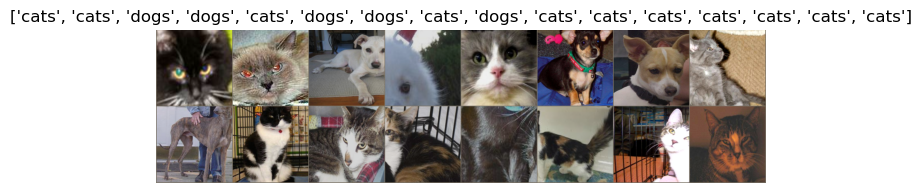

In [ ]:
def imshow(inp, title=None):
    """Reverse normalisation and display a tensor as an image."""
    inp = inp.numpy().transpose((1, 2, 0))       # C×H×W  →  H×W×C
    inp = STD * inp + MEAN                        # un-normalise
    inp = inp.clip(0, 1)
    plt.imshow(inp)
    if title:
        plt.title(title)
    plt.axis("off")

images, labels = next(iter(train_loader))
grid = torchvision.utils.make_grid(images[:16])

imshow(grid, title=[CLASS_NAMES[l] for l in labels[:16]])
plt.tight_layout()
plt.show()

## Cell 4 — Model Definitions

**Transfer learning strategy:**
1. Load pre-trained weights from ImageNet.
2. **Freeze** all backbone layers, allow their weights to remain changed during training.
3. Replace the final classifier layer with a new one outputting **2 classes** (cat / dog).
4. Only the new classifier head is trained.

This is called **feature extraction** — the backbone acts as a fixed feature extractor.

In [ ]:
NUM_CLASSES = 2

def freeze_backbone(model):
    """Freeze all parameters so only the replaced head trains."""
    for param in model.parameters():
        param.requires_grad = False

def build_resnet50():
    """
    ResNet-50 (He et al., 2015)
    ───────────────────────────
    - Introduces residual (skip) connections: x → F(x) + x.
    - Solves vanishing gradient for very deep nets.
    - 50 layers, ~25M parameters.
    """
    m = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
    freeze_backbone(m)
    m.fc = nn.Linear(m.fc.in_features, NUM_CLASSES)         # replace final FC
    return m


# ── Model registry ────────────────────────────────────────────────────────────
MODEL_BUILDERS = {
    "ResNet-50"   : build_resnet50,
}

# Quick sanity check — count trainable parameters for each model
print(f"{'Model':<15} {'Total params':>15} {'Trainable':>12}")
print("-" * 45)
for name, builder in MODEL_BUILDERS.items():
    m = builder()
    total     = sum(p.numel() for p in m.parameters())
    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)
    print(f"{name:<15} {total:>15,} {trainable:>12,}")

Model              Total params    Trainable
---------------------------------------------
ResNet-50            23,512,130        4,098


## Cell 5 — Training & Evaluation Loop

**Key concepts:**

| Concept | Role |
|---|---|
| `CrossEntropyLoss` | Measures how wrong the predicted probability distribution is |
| `Adam` optimiser | Adapts learning rate per parameter — converges faster than plain SGD |
| `StepLR` scheduler | Decays learning rate by 0.1 every 5 epochs — fine-tunes convergence |
| `model.train()` | Enables dropout & batch norm in training mode |
| `model.eval()` | Disables them for deterministic evaluation |
| `torch.no_grad()` | Skips gradient computation during validation — saves memory |

In [ ]:
def train_model(model, name, num_epochs=10, lr=1e-3):
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    # Only pass parameters that require gradients (the new head)
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_val_acc = 0.0
    best_weights = copy.deepcopy(model.state_dict())
    t0 = time.time()

    for epoch in range(num_epochs):
        # ── Training phase ────────────────────────────────────────────────────
        model.train()
        run_loss, run_correct = 0.0, 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()           # clear gradients from last step
            outputs = model(inputs)         # forward pass
            loss = criterion(outputs, labels)
            loss.backward()                 # backpropagation
            optimizer.step()               # update weights

            run_loss    += loss.item() * inputs.size(0)
            run_correct += (outputs.argmax(1) == labels).sum().item()

        epoch_train_loss = run_loss    / len(train_ds)
        epoch_train_acc  = run_correct / len(train_ds)

        # ── Validation phase ──────────────────────────────────────────────────
        model.eval()
        val_loss, val_correct = 0.0, 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss    += loss.item() * inputs.size(0)
                val_correct += (outputs.argmax(1) == labels).sum().item()

        epoch_val_loss = val_loss    / len(val_ds)
        epoch_val_acc  = val_correct / len(val_ds)

        scheduler.step()

        # Track best weights
        if epoch_val_acc > best_val_acc:
            best_val_acc = epoch_val_acc
            best_weights = copy.deepcopy(model.state_dict())

        history["train_loss"].append(epoch_train_loss)
        history["train_acc"].append(epoch_train_acc)
        history["val_loss"].append(epoch_val_loss)
        history["val_acc"].append(epoch_val_acc)

        print(f"[{name}] Epoch {epoch+1:02d}/{num_epochs} "
              f"| Train Loss {epoch_train_loss:.4f}  Acc {epoch_train_acc:.4f} "
              f"| Val Loss {epoch_val_loss:.4f}  Acc {epoch_val_acc:.4f}")

    elapsed = time.time() - t0
    model.load_state_dict(best_weights)   # restore best checkpoint
    print(f"\n✓ {name} done in {elapsed:.1f}s  |  Best val acc: {best_val_acc:.4f}\n")
    return model, history, elapsed, best_val_acc

## Cell 6 — Train The Model

In [ ]:
EPOCHS = 10   # increase for better accuracy

results  = {}   # stores history dicts
summaries = []  # for the comparison table

for model_name, builder in MODEL_BUILDERS.items():
    print("=" * 65)
    print(f"  Training: {model_name}")
    print("=" * 65)
    model = builder()
    trained_model, history, elapsed, best_acc = train_model(model, model_name, num_epochs=EPOCHS)

    results[model_name] = {
        "model"  : trained_model,
        "history": history,
    }

    total_params = sum(p.numel() for p in trained_model.parameters())
    summaries.append({
        "Model"         : model_name,
        "Params (M)"    : round(total_params / 1e6, 2),
        "Train time (s)": round(elapsed, 1),
        "Best Val Acc"  : round(best_acc, 4),
    })

print("\nAll models trained.")

  Training: ResNet-50
[ResNet-50] Epoch 01/10 | Train Loss 0.3546  Acc 0.8655 | Val Loss 0.1354  Acc 0.9740
[ResNet-50] Epoch 02/10 | Train Loss 0.2046  Acc 0.9225 | Val Loss 0.1041  Acc 0.9630
[ResNet-50] Epoch 03/10 | Train Loss 0.1818  Acc 0.9235 | Val Loss 0.0770  Acc 0.9800
[ResNet-50] Epoch 04/10 | Train Loss 0.1658  Acc 0.9310 | Val Loss 0.0680  Acc 0.9760
[ResNet-50] Epoch 05/10 | Train Loss 0.1450  Acc 0.9445 | Val Loss 0.0628  Acc 0.9760
[ResNet-50] Epoch 06/10 | Train Loss 0.1418  Acc 0.9450 | Val Loss 0.0548  Acc 0.9840
[ResNet-50] Epoch 07/10 | Train Loss 0.1392  Acc 0.9475 | Val Loss 0.0555  Acc 0.9820
[ResNet-50] Epoch 08/10 | Train Loss 0.1388  Acc 0.9430 | Val Loss 0.0528  Acc 0.9850
[ResNet-50] Epoch 09/10 | Train Loss 0.1340  Acc 0.9525 | Val Loss 0.0558  Acc 0.9830
[ResNet-50] Epoch 10/10 | Train Loss 0.1376  Acc 0.9455 | Val Loss 0.0538  Acc 0.9850

✓ ResNet-50 done in 1091.2s  |  Best val acc: 0.9850


All models trained.


## Cell 7 — Test Set Evaluation

In [ ]:
def evaluate_on_test(model):
    model.eval()
    correct = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            preds = model(inputs).argmax(1)
            correct += (preds == labels).sum().item()
    return correct / len(test_ds)


print(f"{'Model':<15} {'Test Accuracy':>15}")
print("-" * 32)
for i, entry in enumerate(summaries):
    name  = entry["Model"]
    model = results[name]["model"]
    test_acc = evaluate_on_test(model)
    summaries[i]["Test Acc"] = round(test_acc, 4)
    print(f"{name:<15} {test_acc:>15.4f}")

Model             Test Accuracy
--------------------------------
ResNet-50                0.9830


## Cell 8 — Loss & Accuracy Curves

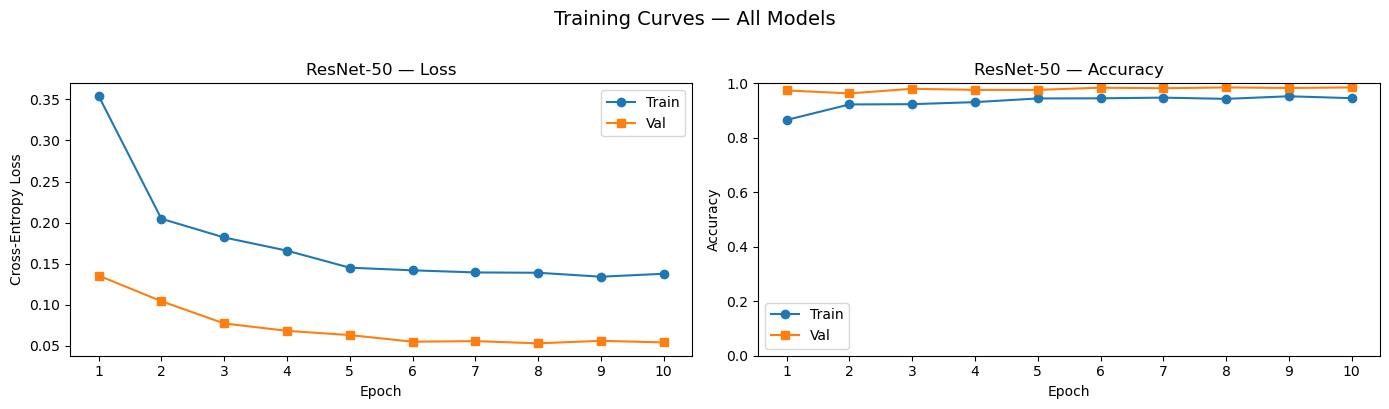

In [ ]:
fig, axes = plt.subplots(len(MODEL_BUILDERS), 2, figsize=(14, 4 * len(MODEL_BUILDERS)))

for row, (name, data) in enumerate(results.items()):
    h = data["history"]
    epochs = range(1, len(h["train_loss"]) + 1)

    # Loss
    axes[0].plot(epochs, h["train_loss"], label="Train", marker="o")
    axes[0].plot(epochs, h["val_loss"],   label="Val",   marker="s")
    axes[0].set_title(f"{name} — Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Cross-Entropy Loss")
    axes[0].legend()
    axes[0].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

    # Accuracy
    axes[1].plot(epochs, h["train_acc"], label="Train", marker="o")
    axes[1].plot(epochs, h["val_acc"],   label="Val",   marker="s")
    axes[1].set_title(f"{name} — Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].set_ylim(0, 1)
    axes[1].legend()
    axes[1].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

plt.suptitle("Training Curves — All Models", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(RESULT_DIR + "training_curves.png", bbox_inches="tight", dpi=120)
plt.show()

## Cell 9 — Prediction Visualisation

           Params (M)  Train time (s)  Best Val Acc  Test Acc
Model                                                        
ResNet-50       23.51          1091.2         0.985     0.983


c:\Users\v303\anaconda3\envs\hsi-torch\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


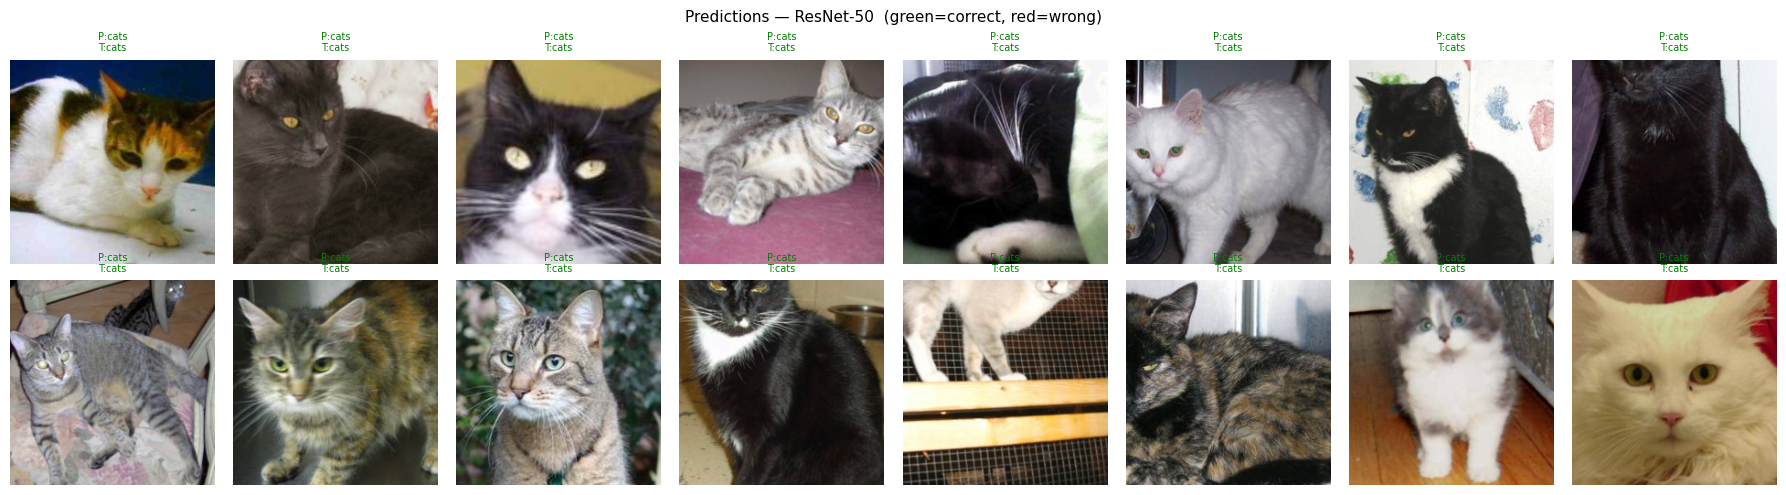

In [ ]:
df = pd.DataFrame(summaries).set_index("Model")
df = df.sort_values("Test Acc", ascending=False)
print(df.to_string())

best_model_name = df.index[0]   # top row after sorting by Test Acc
best_model = results[best_model_name]["model"]
best_model.eval()

images, labels = next(iter(test_loader))
images_gpu = images.to(device)

with torch.no_grad():
    outputs = best_model(images_gpu)
    preds   = outputs.argmax(1).cpu()

fig, axes = plt.subplots(2, 8, figsize=(18, 5))
for i, ax in enumerate(axes.flatten()):
    if i >= len(images): break
    img = images[i].numpy().transpose(1, 2, 0)
    img = (img * STD + MEAN).clip(0, 1)
    ax.imshow(img)
    colour = "green" if preds[i] == labels[i] else "red"
    ax.set_title(f"P:{CLASS_NAMES[preds[i]]}\nT:{CLASS_NAMES[labels[i]]}",
                 color=colour, fontsize=7)
    ax.axis("off")

plt.suptitle(f"Predictions — {best_model_name}  (green=correct, red=wrong)", fontsize=11)
plt.tight_layout()
plt.show()